<a href="https://colab.research.google.com/github/galihtw04/data-science-2026/blob/master/Pertemuan10_Muhammad_Galih_Abdurrahman_240401010278.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
# load library
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE

In [31]:
# Upload file dataset
from google.colab import files
uploaded = files.upload()

In [32]:
# Test baca dataset
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
print("Shape dataset:", df.shape)
print('\n')
df.head()

Shape dataset: (7043, 21)




,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [33]:
# Step 4A - Copy data dan drop kolom identifier

data = df.copy()

# customerID hanya ID pelanggan, bukan fitur prediksi
if "customerID" in data.columns:
    data = data.drop(columns=["customerID"])

data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [34]:
# Cek tipe data dan missing value awal

print("Jumlah baris dan kolom:")
print(data.shape)

print("\nTipe data per kolom:")
display(data.dtypes)

print("\nMissing value per kolom:")
display(data.isnull().sum())

Jumlah baris dan kolom:
(7043, 20)

Tipe data per kolom:


,0
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object
OnlineBackup,object



Missing value per kolom:


,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [35]:
# Konversi TotalCharges ke numeric

data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors="coerce")

print("Tipe data TotalCharges setelah konversi:")
print(data["TotalCharges"].dtype)

print("\nMissing value setelah TotalCharges dikonversi:")
display(data.isnull().sum())

Tipe data TotalCharges setelah konversi:
float64

Missing value setelah TotalCharges dikonversi:


,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [36]:
# Isi missing value

# Isi missing value numeric dengan median
for col in data.select_dtypes(include=["int64", "float64"]).columns:
    data[col] = data[col].fillna(data[col].median())

# Isi missing value kategorikal dengan modus
for col in data.select_dtypes(include=["object"]).columns:
    data[col] = data[col].fillna(data[col].mode()[0])

print("Total missing value setelah dibersihkan:")
print(data.isnull().sum().sum())

Total missing value setelah dibersihkan:
0


In [37]:
# Cek distribusi target Churn

print("Jumlah data per kelas:")
display(data["Churn"].value_counts())

print("\nProporsi data per kelas (%):")
display(data["Churn"].value_counts(normalize=True) * 100)

Jumlah data per kelas:


,count
Churn,
No,5174
Yes,1869



Proporsi data per kelas (%):


,proportion
Churn,
No,73.463013
Yes,26.536987


In [38]:
# Encoding target Churn

data["Churn"] = data["Churn"].map({
    "No": 0,
    "Yes": 1
})

data["Churn"].value_counts()

,count
Churn,
0,5174
1,1869


In [39]:
# Pisahkan fitur dan target

X = data.drop(columns=["Churn"])
y = data["Churn"]

print("Shape X sebelum encoding:", X.shape)
print("Shape y:", y.shape)

Shape X sebelum encoding: (7043, 19)
Shape y: (7043,)


In [40]:
# Encoding fitur kategorikal

X_encoded = pd.get_dummies(X, drop_first=True)

print("Shape X setelah encoding:", X_encoded.shape)
X_encoded.head()

Shape X setelah encoding: (7043, 30)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False


In [41]:
# Split data train dan test secara stratified

X_tr, X_te, y_tr, y_te = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Shape X_train:", X_tr.shape)
print("Shape X_test :", X_te.shape)
print("Shape y_train:", y_tr.shape)
print("Shape y_test :", y_te.shape)

Shape X_train: (5634, 30)
Shape X_test : (1409, 30)
Shape y_train: (5634,)
Shape y_test : (1409,)


In [42]:
# Cek proporsi Churn pada train dan test

print("Proporsi Churn pada data train (%):")
display(y_tr.value_counts(normalize=True) * 100)

print("\nProporsi Churn pada data test (%):")
display(y_te.value_counts(normalize=True) * 100)

Proporsi Churn pada data train (%):


,proportion
Churn,
0,73.464679
1,26.535321



Proporsi Churn pada data test (%):


,proportion
Churn,
0,73.456352
1,26.543648


Train-test split menggunakan stratify=y agar proporsi kelas Churn pada data train dan test tetap mirip dengan dataset asli.

In [43]:
# Latih model Random Forest

rf = RandomForestClassifier(
    n_estimators=300,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42
)

rf.fit(X_tr, y_tr)

print("Model Random Forest berhasil dilatih.")

Model Random Forest berhasil dilatih.


In [44]:
# Prediksi label dan probabilitas

y_pred = rf.predict(X_te)
y_proba = rf.predict_proba(X_te)[:, 1]

print("Prediksi berhasil dibuat.")

Prediksi berhasil dibuat.


In [45]:
# Classification report

print(classification_report(y_te, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.63      0.50      0.56       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



Pada kasus customer churn, metrik recall untuk kelas 1 perlu diperhatikan karena menunjukkan seberapa banyak pelanggan churn yang berhasil terdeteksi oleh model.

In [46]:
# Confusion matrix

cm = confusion_matrix(y_te, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=["Actual Tidak Churn", "Actual Churn"],
    columns=["Pred Tidak Churn", "Pred Churn"]
)

display(cm_df)

,Pred Tidak Churn,Pred Churn
Actual Tidak Churn,925,110
Actual Churn,187,187


In [47]:
# ROC-AUC

roc_auc = roc_auc_score(y_te, y_proba)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.8246208891988943


In [48]:
# Tabel hasil prediksi probabilitas churn

hasil_prediksi = pd.DataFrame({
    "Actual_Churn": y_te.values,
    "Predicted_Churn": y_pred,
    "Probability_Churn": y_proba
})

hasil_prediksi.head(10)

,Actual_Churn,Predicted_Churn,Probability_Churn
0,0,0,0.000000
1,0,1,0.786667
2,0,0,0.090000
3,0,0,0.280000
4,0,0,0.000000
5,0,0,0.416667
6,0,0,0.393333
7,0,0,0.110000
8,0,0,0.006667
9,1,0,0.460000


In [49]:
# Top 10 probabilitas churn tertinggi

hasil_prediksi.sort_values(
    by="Probability_Churn",
    ascending=False
).head(10)

,Actual_Churn,Predicted_Churn,Probability_Churn
1289,1,1,1.000000
171,1,1,0.993333
341,1,1,0.990000
618,1,1,0.990000
1252,1,1,0.986667
629,0,1,0.986667
889,0,1,0.970000
1178,1,1,0.963333
1109,1,1,0.960000
788,1,1,0.950000


In [50]:
# Threshold tuning

threshold = 0.35
y_pred_threshold = (y_proba >= threshold).astype(int)

print("Threshold yang digunakan:", threshold)

Threshold yang digunakan: 0.35


In [51]:
# Evaluasi setelah threshold tuning

print(classification_report(y_te, y_pred_threshold))

              precision    recall  f1-score   support

           0       0.87      0.80      0.83      1035
           1       0.55      0.68      0.61       374

    accuracy                           0.77      1409
   macro avg       0.71      0.74      0.72      1409
weighted avg       0.79      0.77      0.77      1409



In [52]:
# SMOTE hanya pada data train

smote = SMOTE(random_state=42)

X_tr_smote, y_tr_smote = smote.fit_resample(X_tr, y_tr)

print("Distribusi sebelum SMOTE:")
display(y_tr.value_counts())

print("\nDistribusi setelah SMOTE:")
display(y_tr_smote.value_counts())

Distribusi sebelum SMOTE:


,count
Churn,
0,4139
1,1495



Distribusi setelah SMOTE:


,count
Churn,
0,4139
1,4139


In [55]:
# Latih Random Forest dengan data hasil SMOTE

rf_smote = RandomForestClassifier(
    n_estimators=300,
    max_features="sqrt",
    random_state=42
)

rf_smote.fit(X_tr_smote, y_tr_smote)

print("Model Random Forest dengan SMOTE berhasil dilatih.")

Model Random Forest dengan SMOTE berhasil dilatih.


In [56]:
# Evaluasi model SMOTE pada data test asli

y_pred_smote = rf_smote.predict(X_te)
y_proba_smote = rf_smote.predict_proba(X_te)[:, 1]

print(classification_report(y_te, y_pred_smote))
print("ROC-AUC:", roc_auc_score(y_te, y_proba_smote))

              precision    recall  f1-score   support

           0       0.85      0.84      0.84      1035
           1       0.57      0.59      0.58       374

    accuracy                           0.77      1409
   macro avg       0.71      0.71      0.71      1409
weighted avg       0.77      0.77      0.77      1409

ROC-AUC: 0.8212754139864114


In [57]:
# Bandingkan hasil model

print("=== Random Forest Class Weight Balanced ===")
print(classification_report(y_te, y_pred))
print("ROC-AUC:", roc_auc_score(y_te, y_proba))

print("\n=== Random Forest SMOTE ===")
print(classification_report(y_te, y_pred_smote))
print("ROC-AUC:", roc_auc_score(y_te, y_proba_smote))

=== Random Forest Class Weight Balanced ===
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.63      0.50      0.56       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409

ROC-AUC: 0.8246208891988943

=== Random Forest SMOTE ===
              precision    recall  f1-score   support

           0       0.85      0.84      0.84      1035
           1       0.57      0.59      0.58       374

    accuracy                           0.77      1409
   macro avg       0.71      0.71      0.71      1409
weighted avg       0.77      0.77      0.77      1409

ROC-AUC: 0.8212754139864114


In [58]:
# Feature importance

feature_importance = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance.head(10)

,Feature,Importance
3,TotalCharges,0.177844
1,tenure,0.164403
2,MonthlyCharges,0.151054
25,Contract_Two year,0.059944
10,InternetService_Fiber optic,0.042323
28,PaymentMethod_Electronic check,0.036455
24,Contract_One year,0.029412
13,OnlineSecurity_Yes,0.028447
4,gender_Male,0.025604
26,PaperlessBilling_Yes,0.024087


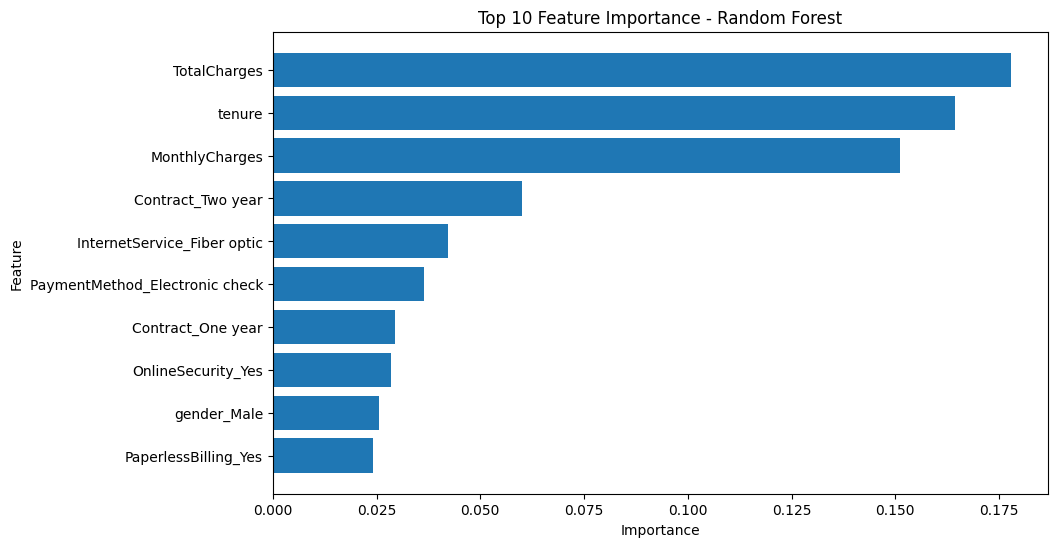

In [59]:
# Visualisasi top 10 feature importance

top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importance - Random Forest")
plt.show()

## Kesimpulan

Pada project **Customer Churn Prediction** ini, materi utama yang dipelajari adalah penerapan algoritma klasifikasi untuk memprediksi apakah seorang pelanggan berpotensi berhenti menggunakan layanan atau tidak. Dataset yang digunakan adalah **Telco Customer Churn**, dengan target prediksi berupa kolom **Churn** yang memiliki dua kelas, yaitu `Yes` dan `No`. Dari hasil eksplorasi, data pelanggan churn memiliki proporsi lebih kecil dibandingkan pelanggan yang tidak churn, sehingga dataset ini termasuk **imbalanced dataset**.

Materi pertama yang dipelajari adalah **preprocessing data**. Tahap ini berfungsi untuk menyiapkan data mentah agar dapat digunakan oleh model machine learning. Beberapa proses yang dilakukan meliputi menghapus kolom yang tidak relevan seperti `customerID`, mengubah kolom `TotalCharges` menjadi numerik, menangani missing value, serta melakukan encoding pada fitur kategorikal. Preprocessing penting karena model machine learning tidak dapat bekerja optimal jika data masih memiliki format yang tidak sesuai.

Materi berikutnya adalah **train-test split dengan stratify**. Teknik ini digunakan untuk membagi dataset menjadi data latih dan data uji dengan tetap menjaga proporsi kelas target. Hal ini penting pada kasus churn karena data bersifat tidak seimbang. Dengan menggunakan `stratify`, proporsi pelanggan churn dan tidak churn pada data train dan test tetap mirip dengan dataset asli, sehingga evaluasi model menjadi lebih valid.

Pada tahap pemodelan, digunakan algoritma **Random Forest Classifier**. Random Forest merupakan metode ensemble learning berbasis banyak decision tree yang digabungkan untuk menghasilkan prediksi yang lebih stabil dan akurat. Dalam project ini, Random Forest digunakan untuk memprediksi pelanggan yang berpotensi churn berdasarkan fitur-fitur seperti kontrak layanan, biaya bulanan, masa berlangganan, metode pembayaran, dan jenis layanan internet. Parameter `class_weight="balanced"` digunakan agar model lebih memperhatikan kelas minoritas, yaitu pelanggan yang churn.

Materi penting lainnya adalah **evaluasi model klasifikasi**. Evaluasi dilakukan menggunakan **precision**, **recall**, **F1-score**, **confusion matrix**, dan **ROC-AUC**. Pada kasus customer churn, metrik **recall untuk kelas 1 (Churn)** menjadi sangat penting karena perusahaan ingin menangkap sebanyak mungkin pelanggan yang benar-benar berisiko berhenti. Akurasi saja tidak cukup karena pada imbalanced dataset, model bisa terlihat memiliki akurasi tinggi walaupun gagal mendeteksi pelanggan churn.

Selain itu, project ini juga mempelajari **SMOTE** sebagai teknik penanganan imbalanced dataset. SMOTE digunakan untuk membuat data sintetis pada kelas minoritas agar jumlah data churn menjadi lebih seimbang dengan kelas tidak churn. Teknik ini hanya diterapkan pada data training, bukan data testing, agar evaluasi tetap mencerminkan kondisi data asli. SMOTE berfungsi sebagai pembanding terhadap pendekatan `class_weight="balanced"` untuk melihat metode mana yang lebih baik dalam mendeteksi pelanggan churn.

Project ini juga memperkenalkan konsep **threshold tuning**, yaitu mengubah ambang batas prediksi dari default `0.5` menjadi nilai lain seperti `0.35`. Threshold tuning digunakan untuk membuat model lebih sensitif dalam mendeteksi churn. Dengan menurunkan threshold, recall pelanggan churn dapat meningkat, tetapi precision bisa menurun karena lebih banyak pelanggan normal yang ikut diprediksi sebagai churn. Oleh karena itu, pemilihan threshold harus disesuaikan dengan kebutuhan bisnis.

Secara keseluruhan, project ini menunjukkan bahwa machine learning dapat digunakan untuk membantu perusahaan dalam mengambil keputusan berbasis data. Model prediksi churn dapat membantu perusahaan mengidentifikasi pelanggan dengan risiko churn tinggi sehingga tim bisnis dapat melakukan strategi retensi lebih awal, seperti memberikan promo, peningkatan layanan, atau pendekatan personal. Dengan demikian, materi yang dipelajari tidak hanya berfokus pada pembuatan model, tetapi juga pada bagaimana hasil model dapat digunakan untuk mendukung keputusan bisnis.